#  CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, datasets, callbacks

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: False


#  Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3552s 21us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


##  Visualize Sample Images

/tmp/ipykernel_2705/3926428376.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])], fontsize=8)


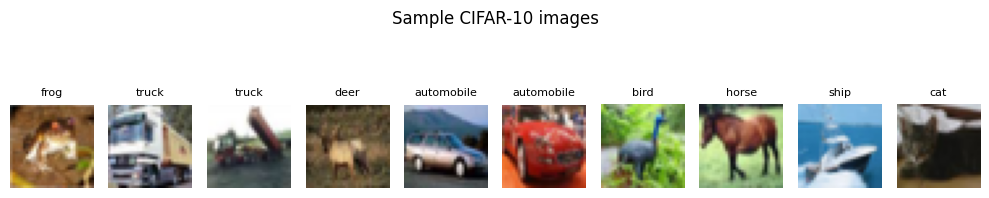

In [4]:
plt.figure(figsize=(10, 2.5))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])], fontsize=8)
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 images")
plt.tight_layout()
plt.show()

# Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

print("Pixel value range after normalization:",
      x_train_norm.min(), "to", x_train_norm.max())

Pixel value range after normalization: 0.0 to 1.0


#  Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
def build_ann(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Flatten(input_shape=input_shape),

        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.4),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.4),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ], name="ANN_deep")
    return model

ann_model = build_ann()
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "ANN_deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

#  Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name="CNN_32_64_128")
    return model

cnn_model = build_cnn()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_32_64_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

## Compiling Models

In [8]:
EPOCHS = 20
BATCH_SIZE = 64

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print(f"Training config -> epochs: {EPOCHS}, batch_size: {BATCH_SIZE}, "
      f"early_stopping: patience=3 on val_loss")

Training config -> epochs: 20, batch_size: 64, early_stopping: patience=3 on val_loss


# Train ANN

In [9]:
print("Training ANN...")
history_ann = ann_model.fit(
    x_train_norm, y_train_flat,
    validation_data=(x_test_norm, y_test_flat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Training ANN...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - accuracy: 0.1640 - loss: 2.1804 - val_accuracy: 0.2377 - val_loss: 2.0800
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.2133 - loss: 2.0586 - val_accuracy: 0.2770 - val_loss: 1.9732
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.2347 - loss: 2.0163 - val_accuracy: 0.2800 - val_loss: 1.9674
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.2423 - loss: 1.9918 - val_accuracy: 0.2841 - val_loss: 1.9578
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - accuracy: 0.2516 - loss: 1.9782 - val_accuracy: 0.2972 - val_loss: 1.9370
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.2518 - loss: 1.9750 - val_accuracy: 0.2786 - val_loss: 1.9629
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.2560 - loss: 1.9671 - val_accuracy: 0.2888 - val_loss: 1.9573
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.2591 -

# Train CNN

In [10]:
print("Training CNN...")
early_stop_cnn = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_cnn = cnn_model.fit(
    x_train_norm, y_train_flat,
    validation_data=(x_test_norm, y_test_flat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_cnn],
    verbose=1
)

Training CNN...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 154s 193ms/step - accuracy: 0.4862 - loss: 1.4473 - val_accuracy: 0.5438 - val_loss: 1.2777
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 194ms/step - accuracy: 0.6353 - loss: 1.0431 - val_accuracy: 0.6388 - val_loss: 1.0296
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 196s 186ms/step - accuracy: 0.6961 - loss: 0.8670 - val_accuracy: 0.6413 - val_loss: 1.0622
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 205s 190ms/step - accuracy: 0.7362 - loss: 0.7533 - val_accuracy: 0.6924 - val_loss: 0.9678
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 149s 191ms/step - accuracy: 0.7722 - loss: 0.6560 - val_accuracy: 0.7060 - val_loss: 0.9221
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 193ms/step - accuracy: 0.7961 - loss: 0.5774 - val_accuracy: 0.7386 - val_loss: 0.8276
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 188ms/step - accuracy: 0.8210 - loss: 0.5100 - val_accuracy: 0.7540 - val_loss: 0.7478
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 190ms/step - ac

# Compare Learning Curves

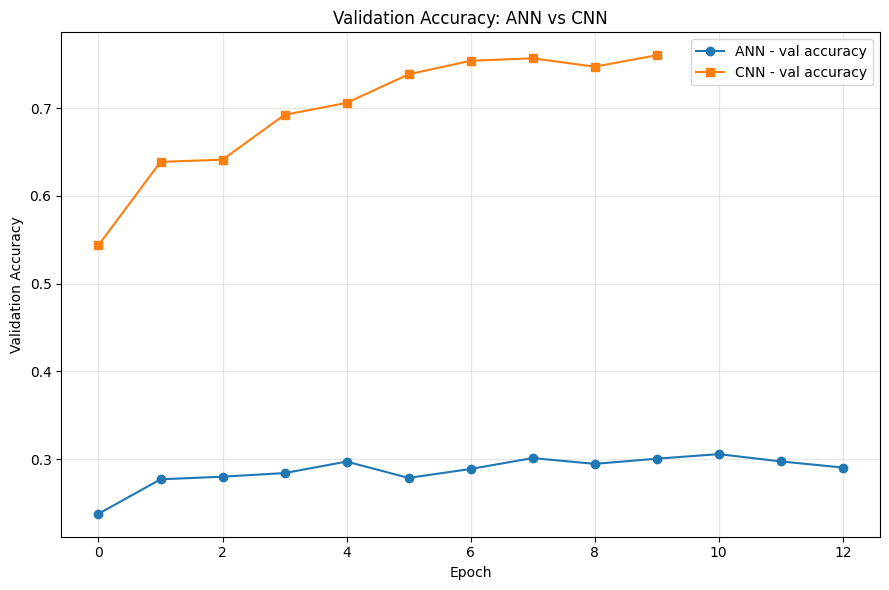

In [11]:
plt.figure(figsize=(9, 6))
plt.plot(history_ann.history['val_accuracy'], label='ANN - val accuracy', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN - val accuracy', marker='s')
plt.title('Validation Accuracy: ANN vs CNN')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ann_vs_cnn_val_accuracy.png', dpi=150)
plt.show()

# Part 3: Data Augmentation CNN


In [12]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

def build_augmented_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="CNN_augmented_32_64_128")
    return model

augmented_cnn_model = build_augmented_cnn()
augmented_cnn_model.summary()

Model: "CNN_augmented_32_64_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

# Train augmented CNN

In [13]:
augmented_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_aug = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Training augmented CNN...")
history_aug_cnn = augmented_cnn_model.fit(
    x_train_norm, y_train_flat,
    validation_data=(x_test_norm, y_test_flat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_aug],
    verbose=1
)

Training augmented CNN...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 167s 207ms/step - accuracy: 0.4178 - loss: 1.6369 - val_accuracy: 0.5267 - val_loss: 1.3380
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 158s 202ms/step - accuracy: 0.5224 - loss: 1.3424 - val_accuracy: 0.5259 - val_loss: 1.3673
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 204s 205ms/step - accuracy: 0.5736 - loss: 1.2095 - val_accuracy: 0.6266 - val_loss: 1.0763
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 160s 205ms/step - accuracy: 0.6066 - loss: 1.1198 - val_accuracy: 0.6442 - val_loss: 1.0208
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 158s 203ms/step - accuracy: 0.6277 - loss: 1.0589 - val_accuracy: 0.6170 - val_loss: 1.0935
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 163s 209ms/step - accuracy: 0.6519 - loss: 1.0046 - val_accuracy: 0.6735 - val_loss: 0.9403
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 161s 206ms/step - accuracy: 0.6653 - loss: 0.9636 - val_accuracy: 0.6927 - val_loss: 0.9053
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 202ms

# Visualizing Models

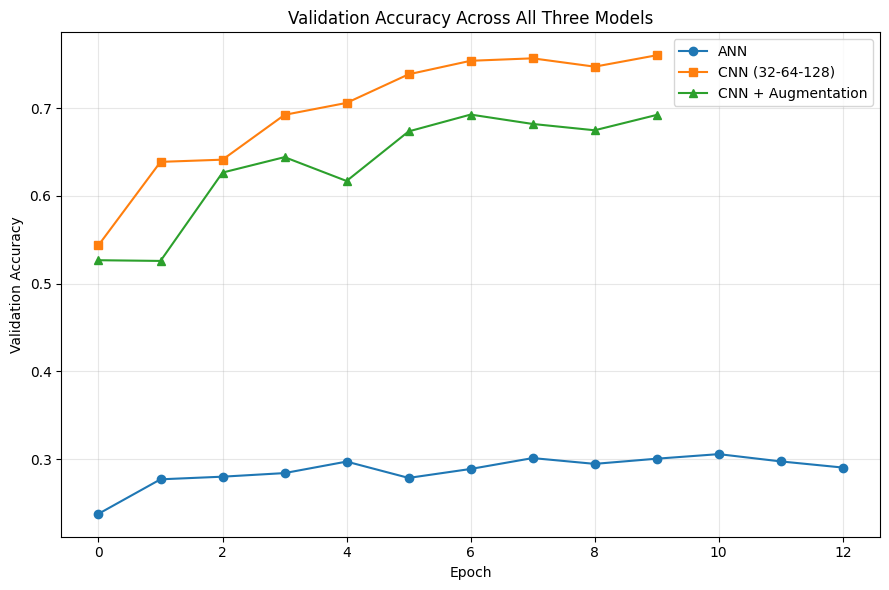

In [14]:
plt.figure(figsize=(9, 6))
plt.plot(history_ann.history['val_accuracy'], label='ANN', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN (32-64-128)', marker='s')
plt.plot(history_aug_cnn.history['val_accuracy'], label='CNN + Augmentation', marker='^')
plt.title('Validation Accuracy Across All Three Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('all_models_val_accuracy.png', dpi=150)
plt.show()

#  Final Comparison Table

In [15]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_norm, y_test_flat, verbose=0)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test_flat, verbose=0)
aug_test_loss, aug_test_acc = augmented_cnn_model.evaluate(x_test_norm, y_test_flat, verbose=0)

results_df = pd.DataFrame({
    'Model': ['ANN (deep, Dense+Dropout)', 'CNN (32-64-128 filters)', 'CNN + Data Augmentation'],
    'Test Accuracy': [ann_test_acc, cnn_test_acc, aug_test_acc],
    'Test Loss': [ann_test_loss, cnn_test_loss, aug_test_loss],
    'Epochs Trained': [len(history_ann.history['loss']),
                       len(history_cnn.history['loss']),
                       len(history_aug_cnn.history['loss'])],
    'Total Params': [ann_model.count_params(),
                      cnn_model.count_params(),
                      augmented_cnn_model.count_params()]
})
results_df['Test Accuracy'] = results_df['Test Accuracy'].round(4)
results_df['Test Loss'] = results_df['Test Loss'].round(4)

print(results_df.to_string(index=False))
results_df

                    Model  Test Accuracy  Test Loss  Epochs Trained  Total Params
ANN (deep, Dense+Dropout)         0.3005     1.9113              13       3837066
  CNN (32-64-128 filters)         0.7540     0.7478              10        621258
  CNN + Data Augmentation         0.6927     0.9053              10        621258


,Model,Test Accuracy,Test Loss,Epochs Trained,Total Params
0,"ANN (deep, Dense+Dropout)",0.3005,1.9113,13,3837066
1,CNN (32-64-128 filters),0.7540,0.7478,10,621258
2,CNN + Data Augmentation,0.6927,0.9053,10,621258


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [16]:
print("TASK 1 — ANN layers")
print("ANN final test accuracy:", round(ann_test_acc, 4))
print("ANN architecture (layer count):", len(ann_model.layers))
print()

print("TASK 2 — CNN filters 32->64->128")
for layer in cnn_model.layers:
    if isinstance(layer, layers.Conv2D):
        print(f"{layer.name}: filters = {layer.filters}")
print()

print("TASK 3 — Epochs = 20")
print("Epochs configured:", EPOCHS)
print("Epochs ANN actually ran:", len(history_ann.history['loss']))
print("Epochs CNN actually ran:", len(history_cnn.history['loss']))
print()

print("TASK 4 — EarlyStopping")
print("Monitor:", early_stop.monitor, "| Patience:", early_stop.patience)
print()

print("TASK 5 — Data augmentation")
print("Augmentation layers used:", [l.name for l in data_augmentation.layers])
print("Augmented CNN final test accuracy:", round(aug_test_acc, 4))

TASK 1 — ANN layers
ANN final test accuracy: 0.3005
ANN architecture (layer count): 10

TASK 2 — CNN filters 32->64->128
conv2d: filters = 32
conv2d_1: filters = 64
conv2d_2: filters = 128

TASK 3 — Epochs = 20
Epochs configured: 20
Epochs ANN actually ran: 13
Epochs CNN actually ran: 10

TASK 4 — EarlyStopping
Monitor: val_loss | Patience: 3

TASK 5 — Data augmentation
Augmentation layers used: ['random_flip', 'random_rotation', 'random_zoom']
Augmented CNN final test accuracy: 0.6927


# Summary

In [17]:
print("="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)
best_model_idx = results_df['Test Accuracy'].idxmax()
print(f"Best performing model: {results_df.loc[best_model_idx, 'Model']} "
      f"with {results_df.loc[best_model_idx, 'Test Accuracy']} test accuracy")

FINAL RESULTS SUMMARY
                    Model  Test Accuracy  Test Loss  Epochs Trained  Total Params
ANN (deep, Dense+Dropout)         0.3005     1.9113              13       3837066
  CNN (32-64-128 filters)         0.7540     0.7478              10        621258
  CNN + Data Augmentation         0.6927     0.9053              10        621258
Best performing model: CNN (32-64-128 filters) with 0.754 test accuracy


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**